In [1]:
import numpy as np
import pandas as pd
import time  #统计运行时间用
import copy  #深拷贝的时候用
import _pickle as cPickle
import gc #释放内存使用
import datetime #处理时间数据
import os
from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号
import seaborn as sns
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns',100)
pd.set_option('max_colwidth',100)
#原始数据集
bike=pd.read_csv("F:/AAAAAAAAAAAAAAAAAAAAA/Senior/subject/数据挖掘/实验二/day.csv",parse_dates=['dteday'])
bike['season']=bike['season'].map({1:'WINTER',2:'SPRING',3:'SUMMER',4:'FALL'})
bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,WINTER,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,WINTER,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,WINTER,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,WINTER,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,WINTER,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [2]:
#添加特征days_since_2011，自数据集中第一天（20110101）起的天数），引入此特征为了考虑随时间变化的趋势
bike['days_since_2011']= (bike['dteday']-min(bike['dteday'])).dt.days
#原始数据集中的几个特征进行了标准化，这里还原到原始值
# denormalize weather features:
# temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
bike['temp'] = bike['temp'] * (39 - (-8)) + (-8)
# windspeed: Normalized wind speed. The values are divided to 67 (max)
bike['windspeed'] = 67 * bike['windspeed']
# hum: Normalized humidity. The values are divided to 100 (max)
bike['hum'] = 100 * bike['hum']

#保留的特征：租赁数量cnt(目标变量)，季节，是否假期（1是，0不是），是否工作日（1是，0不是），天气情况（晴、雾、雨雪），温度（单位为℃），湿度（相对湿度百分比0~100%），风速（单位为km/h），天数
select_cols=['cnt','season','holiday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'days_since_2011']
bike=bike[select_cols]
bike.head()

,cnt,season,holiday,workingday,weathersit,temp,hum,windspeed,days_since_2011
0,985,WINTER,0,0,2,8.175849,80.5833,10.749882,0
1,801,WINTER,0,0,2,9.083466,69.6087,16.652113,1
2,1349,WINTER,0,1,1,1.229108,43.7273,16.636703,2
3,1562,WINTER,0,1,1,1.400000,59.0435,10.739832,3
4,1600,WINTER,0,1,1,2.666979,43.6957,12.522300,4


In [3]:
# OneHotEncoder：Encode categorical features as a one-hot numeric array(aka 'one-of-K' or 'dummy')
#Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.
#1.对特征进行独热编码（可以是'one-of-K' or 'dummy'），适用于无序的类别特征。如果对标签进行编码则使用LabelBinarizer
#2.sparse : bool, default=True，默认为稀疏矩阵形式
#3.可以通过参数handle_unknown规定fit中未出现但是transform中出现的值进行'ignore'
#4.可以通过参数categories指定需要保留的取值（指定后可以通过ohe.categories_查看）
#5.灵活使用drop参数，控制如何drop掉多余的列
#更多信息参见ohe?
def f_ohe(df,col,new_names=None,keep_cate='auto'):
   #$
    #【功能】对一个特征进行独热编码
    #【参数】df：dataframe,数据集
    #       col：str,需要进行独热编码的特征名
    #       new_names: dic,如果需要对取值重命名（使特征名更能表达真实意思）,则新建一个字典，默认None则特征名为col_取值
    #       keep_cate: list,需要保留的取值，如果取值是数值型则需要先排序,例如[[1,3,4]];默认'auto'表示保留所有值
    #【返回】dataframe
    #【举例】t_season=f_ohe(df=bike,col='season',new_names={1:'冬',3:'夏',4:'秋'},keep_cate=[[1,3,4]])

   # '''
    ohe=OneHotEncoder(dtype=np.int8,handle_unknown='ignore',sparse_output=False,categories=keep_cate)
    ohe.fit(df[col].values.reshape(-1,1))
    tmp=pd.DataFrame(ohe.transform(df[col].values.reshape(-1,1)))
    org_names=ohe.get_feature_names_out([col]).tolist()  #col作为新生成字段的前缀
    if new_names is None:
        tmp.columns=org_names
    else:
        new_names_keys=list(new_names.keys()) #获取输入的keys
        new_names_keys=[col+'_'+str(item) for item in new_names_keys] #输入的keys加上col前缀
        # print(new_names_keys)
        new_names=dict(zip(new_names_keys,list(new_names.values()))) #加上前缀的keys和输入的values重新打包为字典
        # print(new_names)
        a=list(pd.Series(data=org_names).map(new_names).values) #list不能直接map,把原特征名map转为Series后映射为新特征名
        tmp.columns=[col+'_'+str(item) for item in a]  #加上col前缀

    return tmp

#对于取值有两类的特征（是否假期holiday、是否工作日workingday），由于本身已是0/1编码，因此不作进一步处理
#对于取值>2类的特征（季节season、天气情况weathersit），进行one-hot编码
#季节，以春（取值2）作为参照类别，参照类别不保留
t_season=f_ohe(df=bike,col='season',new_names={1:'冬',3:'夏',4:'秋'},keep_cate=[[1,3,4]])
t_season

#天气情况，以晴天（取值1）作为参照类别，参照类别不保留
t_weathersit=f_ohe(df=bike,col='weathersit',new_names={2:'雾',3:'雨雪'},keep_cate=[[2,3]])
t_weathersit

bike_ohe=pd.concat((bike[['cnt','holiday', 'workingday', 'temp', 'hum', 'windspeed', 'days_since_2011']],
                    t_season,t_weathersit),axis=1)

bike_ohe
#每一行代表某一天的情况。
#cnt：自行车租赁数量(目标变量)
#holiday：是否假期（1是，0不是)
#workingday：是否工作日（1是，0不是），除了假期和双休日的为工作日
#temp：温度（单位为℃）
#hum：湿度（相对湿度百分比0~100%）
#windspeed：风速（单位为km/h）
#days_since_2011：自数据集中第一天（20110101）起的天数，引入此特征为了考虑随时间变化的趋势
#season_冬、season_夏、season_秋：季节特征（1是，0不是），其中春未出现，可由其他三个季节推知，将春作为参照类别
#weathersit_雾、weathersit_雨雪：天气特征（1是，0不是），其中晴未出现，可由其他两个天气情况推知，将晴作为参照类别

,cnt,holiday,workingday,temp,hum,windspeed,days_since_2011,season_冬,season_夏,season_秋,weathersit_雾,weathersit_雨雪
0,985,0,0,8.175849,80.5833,10.749882,0,0,0,0,1,0
1,801,0,0,9.083466,69.6087,16.652113,1,0,0,0,1,0
2,1349,0,1,1.229108,43.7273,16.636703,2,0,0,0,0,0
3,1562,0,1,1.400000,59.0435,10.739832,3,0,0,0,0,0
4,1600,0,1,2.666979,43.6957,12.522300,4,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
726,2114,0,1,3.945849,65.2917,23.458911,726,0,0,0,1,0
727,3095,0,1,3.906651,59.0000,10.416557,727,0,0,0,1,0
728,1341,0,0,3.906651,75.2917,8.333661,728,0,0,0,1,0
729,1796,0,0,4.024151,48.3333,23.500518,729,0,0,0,0,0


验证数据是否满足某些假设
    1.线性：可先不用管。根据基础线性模型建立后的R方判断预测效果。后续如有需要可对基础线性模型进行改造（如添加交互项、使用回归样条等）。
    2.正态性：本节对目标变量的正态性进行了检验，检验通过。
    3.同方差性：必须建模后再判断，此时无法判断。
4.独立性：除了特殊情况（比如对同一人进行重复测量），一般可认为实例之间相互独立。
5.固定特征：测量无误差，一般都可认为是固定特征。
6.不存在多重共线性：本节进行了检验，检验通过。虽然同时计算了相关系数和VIF，但实践时可以直接以VIF的结论为准。

In [4]:
df=bike_ohe
label='cnt'

feas=df.columns.tolist()
feas.remove(label)
print('特征数量:',len(feas))

X_train=df[feas]
y_train=df[label]
print('X_train:',X_train.shape)
print('y_train:',y_train.shape)

特征数量: 11
X_train: (731, 11)
y_train: (731,)


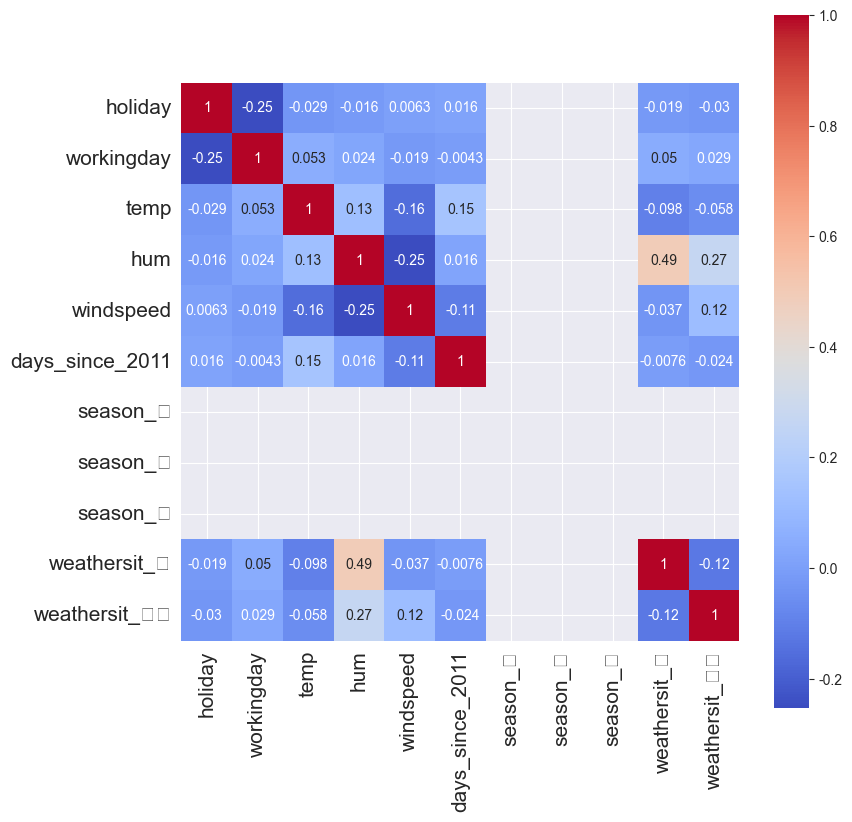

In [5]:
#1.判断共线性
#1.1.计算相关系数（只能判断两两的线性关系）
import matplotlib.pyplot as plt
import seaborn as sns

corr_res=X_train.corr()
plt.subplots(figsize=(9, 9))
sns.heatmap(corr_res, annot=True, vmax=1, square=True, cmap="coolwarm")
plt.xticks(fontsize=15) #放大横纵坐标刻度线上的特征名字体
plt.yticks(fontsize=15)
plt.show()

#如果图显示不完整，关闭jupter notebook后安装
    #pip --default-timeout=100 install matplotlib==3.3.1 -i http://pypi.douban.com/simple/ --trusted-host pypi.douban.com

In [6]:
# 1.2.计算方差膨胀因子（可以判断三个或更多变量之间的线性关系）
from statsmodels.stats.outliers_influence import variance_inflation_factor #计算方差膨胀因子
from statsmodels.tools.tools import add_constant  #添加常量

def checkVIF(df):
   # '''
    #【功能】计算方差膨胀因子
    #【参数】df:dataframe,特征集（不含target）
    #【返回】dataframe，展示各个特征的VIF
    #【参考】当0<VIF<10，不存在多重共线性；当10≤VIF<100，存在较强的多重共线性；当VIF≥100，存在严重多重共线性。
    #【来源与介绍】https://blog.csdn.net/nixiang_888/article/details/122342338
    #【举例】VIF1=checkVIF(X_train)
    #'''
    df = add_constant(df) #添加一列常量const作为截距，全部赋值为1（不会改变原数据集）
    name = df.columns
    x = np.matrix(df)
    VIF_list = [variance_inflation_factor(x,i) for i in range(x.shape[1])]
    VIF = pd.DataFrame({'feature':name,"VIF":VIF_list})
    VIF = VIF.drop(index=0) #删除截距const行
    VIF.sort_values(['VIF'],ascending=False,inplace=True)
    VIF['remark']=np.where(VIF['VIF']>=100,'严重多重共线性',np.where(VIF['VIF']>=10,'较强多重共线性','无多重共线性'))

    return VIF

VIF1=checkVIF(X_train)
VIF1

,feature,VIF,remark
4,hum,1.818964,无多重共线性
10,weathersit_雾,1.574660,无多重共线性
11,weathersit_雨雪,1.287580,无多重共线性
5,windspeed,1.160772,无多重共线性
3,temp,1.114607,无多重共线性
2,workingday,1.076175,无多重共线性
1,holiday,1.069830,无多重共线性
6,days_since_2011,1.033343,无多重共线性
7,season_冬,NaN,无多重共线性
8,season_夏,NaN,无多重共线性


数据量： 731
p值为: 0.07604854254412197
p值> 0.05 符合正态分布


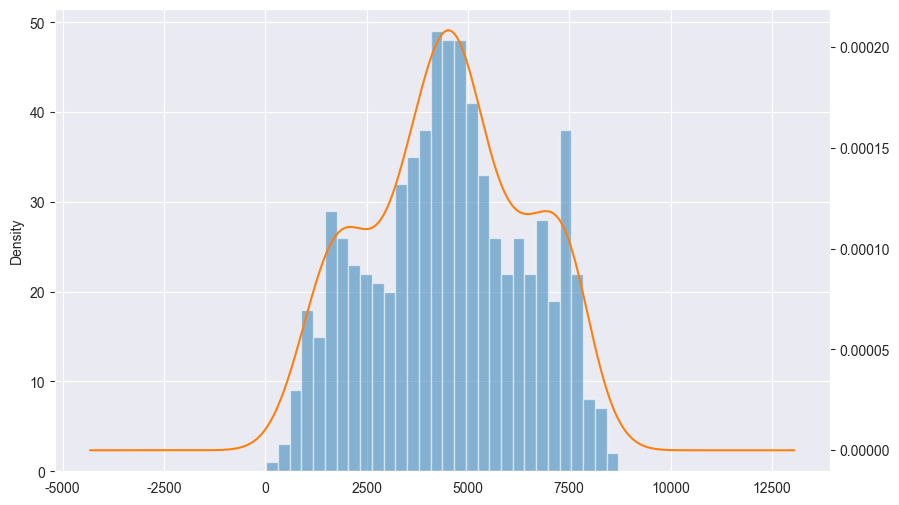

In [7]:
def checkNORM(se,p=0.05,alt='two-sided',if_plot=True):
   # '''
   # 【功能】检验一组数据是否符合正态分布
    #【参数】se:Series
    #       p：float,p值，默认0.05
    #       alt：str,默认双侧检验'two-sided'，可选'less', 'greater'
    #       if_plot,是否画图，默认True
    #【返回】dataframe，展示各个特征的VIF
    #【参考】结果返回两个值：statistic → D值，pvalue → P值
    #【备注】import matplotlib.pyplot as plt
    #       %matplotlib inline
    #【举例】 res=checkNORM(y_train)
   # '''
    from scipy import stats

    print('数据量：',len(se))

    u = se.mean()  # 计算均值
    std = se.std()  # 计算标准差
    res=stats.kstest(rvs=se, cdf='norm',args= (u, std), alternative=alt)
    print('p值为:',res[1])
    if res[1]>p:
        print('p值>',p,'符合正态分布')
    else:
         print('p值<=',p,'不符合正态分布')

    if if_plot==True:
        fig = plt.figure(figsize = (10,6))
        se.hist(bins=30,alpha = 0.5) #直方图 alpha表示透明度
        se.plot(kind = 'kde', secondary_y=True) #核密度估计KDE
        plt.show()


    return res

res=checkNORM(y_train)

In [8]:
from statsmodels.regression.linear_model import OLS,GLS #Ordinary least squares普通最小二乘法
import statsmodels.formula.api as smf
#import statsmodels.api as sm

#建模方式1：使用smf.ols，自己编写formula，会自动添加常数列
#cnt为目标变量，分类特征可使用C(season)进行编码，由于本数据集的分类特征都已事先编码，因此不需要添加c()
model=smf.ols(formula='cnt ~  season_夏 +  season_秋 + season_冬 + holiday + workingday +weathersit_雾 + weathersit_雨雪 + temp + hum + windspeed +days_since_2011 ',data=df)
results=model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     290.7
Date:                Sun, 05 Oct 2025   Prob (F-statistic):          6.17e-220
Time:                        19:58:46   Log-Likelihood:                -6043.4
No. Observations:                 731   AIC:                         1.210e+04
Df Residuals:                     722   BIC:                         1.215e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        2491.2273    254.312      9.796      0.000    1991.948    2990.507
season_夏         4.539e-10   4.77e-11      9.512      0.000     3.6e-10    5.48e-10
season_秋         3.965e-11   3.23e-12     12.262      0.000    3.33e-11     4.6e-11
season_冬         2.782e-12   2.41e-13     11.558      0.000    2.31e-12    3.25e-12
holiday          -720.9808    217.150     -3.320      0.001   -1147.302    -294.660
workingday        126.1078     78.251      1.612      0.107     -27.520     279.735
weathersit_雾     -360.6063     93.039     -3.876      0.000    -543.265    -177.948
weathersit_雨雪   -1937.2251    238.226     -8.132      0.000   -2404.924   -1469.526
temp              117.8414      4.306     27.364      0.000     109.387     126.296
hum               -15.6680      3.323     -4.715      0.000     -22.192      -9.144
windspeed         -38.3459      7.282     -5.266      0.000     -52.642     -24.050
days_since_2011     4.9240      0.169     29.147      0.000       4.592       5.256
==============================================================================
Omnibus:                       79.148   Durbin-Watson:                   0.794
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              149.766
Skew:                          -0.671   Prob(JB):                     3.01e-33
Kurtosis:                       4.765   Cond. No.                     3.74e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 9.46e-30. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [9]:
#将权重表的值组合为一个DataFrame
df_coef=pd.DataFrame(results.params ) #权重
df_coef.reset_index(inplace=True)
df_coef.columns=['feature','coef']
df_coef['lw']=results.conf_int(alpha=0.05)[0].values #获取权重的置信区间下限
df_coef['up']=results.conf_int(alpha=0.05)[1].values #获取权重的置信区间上限
df_coef['SE']=results.bse.values #权重的标准误std err
df_coef['t']=results.tvalues.values #权重的t统计量，等于权重/标准误
df_coef['p']=results.pvalues.values #参数的t统计的双尾 p 值
df_coef['t_abs']=abs(df_coef['t']) #求绝对值
#根据已有的权重和置信区间计算上下误差，计算完毕后发现上下误差相同
df_coef['lw_err']=df_coef['coef']-df_coef['lw']
df_coef['up_err']=df_coef['up']-df_coef['coef']
df_coef

,feature,coef,lw,up,SE,t,p,t_abs,lw_err,up_err
0,Intercept,2.491227e+03,1.991948e+03,2.990507e+03,2.543120e+02,9.795949,2.338693e-21,9.795949,4.992793e+02,4.992793e+02
1,season_夏,4.539368e-10,3.602496e-10,5.476240e-10,4.772033e-11,9.512441,2.708737e-20,9.512441,9.368717e-11,9.368717e-11
2,season_秋,3.964539e-11,3.329788e-11,4.599289e-11,3.233154e-12,12.262140,1.556759e-31,12.262140,6.347506e-12,6.347506e-12
3,season_冬,2.781915e-12,2.309367e-12,3.254464e-12,2.406964e-13,11.557775,1.811510e-28,11.557775,4.725485e-13,4.725485e-13
4,holiday,-7.209808e+02,-1.147302e+03,-2.946597e+02,2.171501e+02,-3.320195,9.447537e-04,3.320195,4.263210e+02,4.263210e+02
5,workingday,1.261078e+02,-2.751965e+01,2.797352e+02,7.825138e+01,1.611573,1.074920e-01,1.611573,1.536274e+02,1.536274e+02
6,weathersit_雾,-3.606063e+02,-5.432651e+02,-1.779476e+02,9.303874e+01,-3.875873,1.159173e-04,3.875873,1.826588e+02,1.826588e+02
7,weathersit_雨雪,-1.937225e+03,-2.404924e+03,-1.469526e+03,2.382264e+02,-8.131867,1.840580e-15,8.131867,4.676991e+02,4.676991e+02
8,temp,1.178414e+02,1.093869e+02,1.262959e+02,4.306380e+00,27.364377,1.155149e-113,27.364377,8.454523e+00,8.454523e+00
9,hum,-1.566796e+01,-2.219193e+01,-9.144001e+00,3.323033e+00,-4.714958,2.901938e-06,4.714958,6.523962e+00,6.523962e+00


In [11]:
#获取置信区间的上下限
pred_ols = results.get_prediction()
iv_l = pred_ols.summary_frame()["obs_ci_lower"]
iv_u = pred_ols.summary_frame()["obs_ci_upper"]

#results.fittedvalues为模型预测值
target_df=pd.concat((y_train,results.fittedvalues,iv_l,iv_u),axis=1)
target_df.columns=['true','predict','ci_lower','ci_upper']
target_df['resid']=results.resid #残差
target_df


,true,predict,ci_lower,ci_upper,resid
0,985,1419.284211,-454.368177,3292.936599,-434.284211
1,801,1476.786235,-396.069098,3349.641568,-675.786235
2,1349,1448.955485,-422.659240,3320.570211,-99.955485
3,1562,1460.164973,-411.783378,3332.113323,101.835027
4,1600,1786.509975,-85.074279,3658.094229,-186.509975
...,...,...,...,...,...
726,2114,4374.015256,2495.596926,6252.433586,-2260.015256
727,3095,4973.019369,3098.931903,6847.106835,-1878.019369
728,1341,4676.448433,2800.523113,6552.373754,-3335.448433
729,1796,4896.621237,3017.662406,6775.580068,-3100.621237


In [27]:
import matplotlib.pyplot as plt
import pandas as pd  # 假设target_df是Pandas DataFrame

# ———— 关键：设置中文字体 ————
plt.rcParams['font.sans-serif'] = ['SimHei']  # 选择支持中文的字体（如“黑体”）
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示异常问题

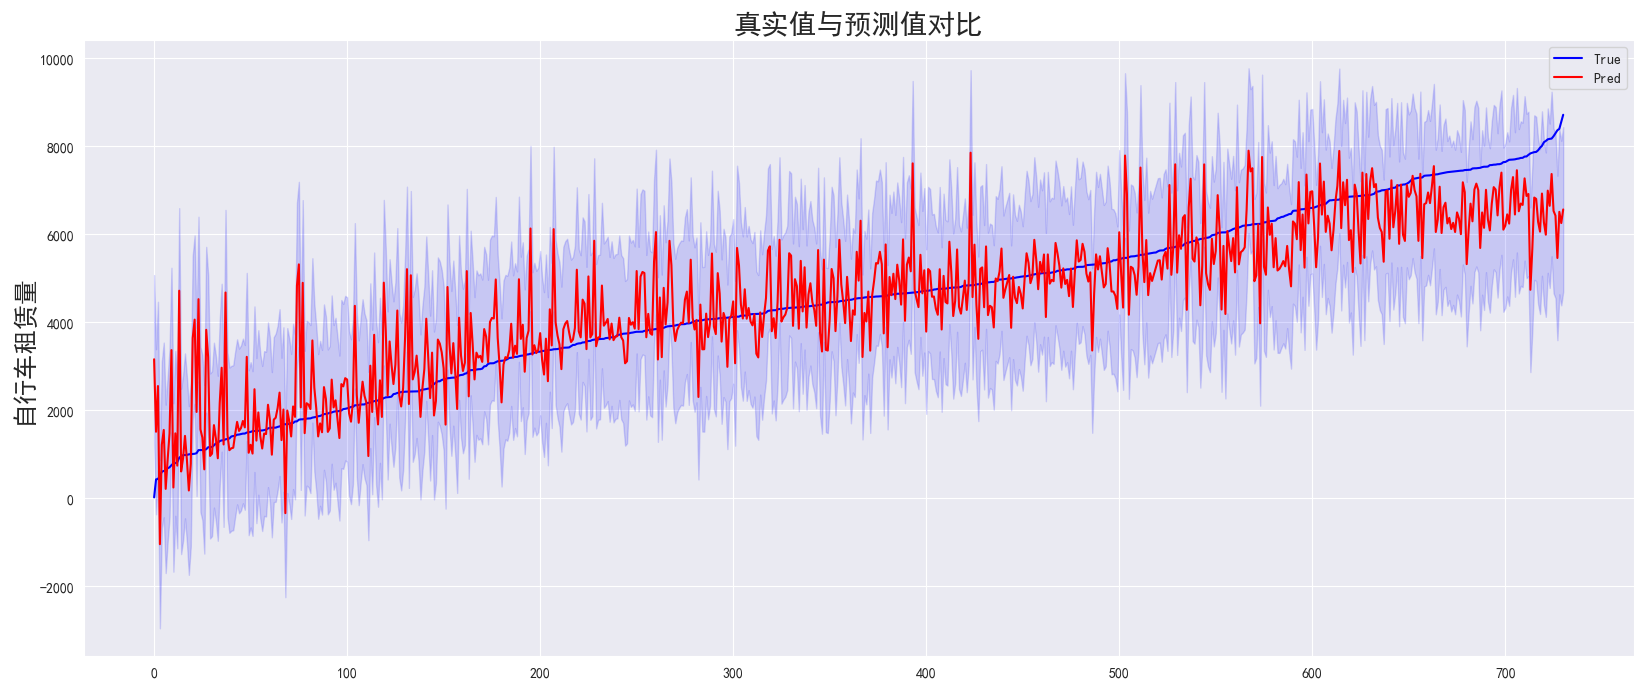

In [15]:

#按实际租赁量排序，reset_index是必须的
plot_df=target_df.sort_values(['true']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(20, 8))

ax.plot(plot_df['true'], "b-", label="True")
ax.plot(plot_df['predict'], "r", label="Pred")
# ax.plot(plot_df['ci_lower'], "r--",alpha=0.5) #置信区间虚线
# ax.plot(plot_df['ci_upper'], "r--",alpha=0.5) #置信区间虚线
plt.fill_between(plot_df.index,plot_df['ci_lower'],plot_df['ci_upper'],color='blue',alpha=0.15)
ax.legend(loc="best")


plt.ylabel('自行车租赁量',fontsize=18)
plt.title('真实值与预测值对比',fontsize=20)
plt.show()
#下图中，蓝线为真实值，红色实线为预测值，蓝紫色为置信区间。
#由下图可知，左侧租赁量较小时，部分预测值远高于真实值且波动较大；右侧租赁量较大时，预测值整体偏低。
#由此图也可以看出，前文中提到的线性回归模型的【同方差性】在现实中是很难满足的。

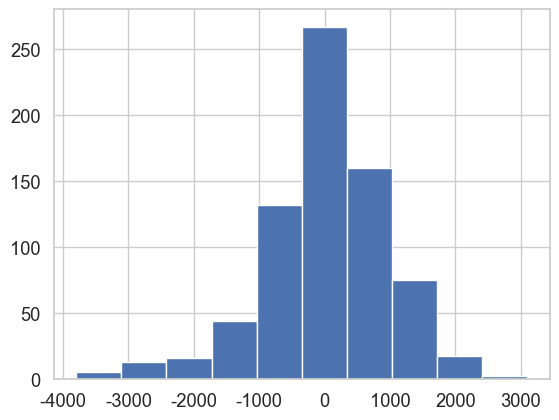

In [16]:
#残差——同方差性
#1.应该为均值是0的正态分布
sns.set(style="whitegrid",font_scale=1.2)#设置主题，文本大小
plt.hist(target_df['resid'])
plt.show()

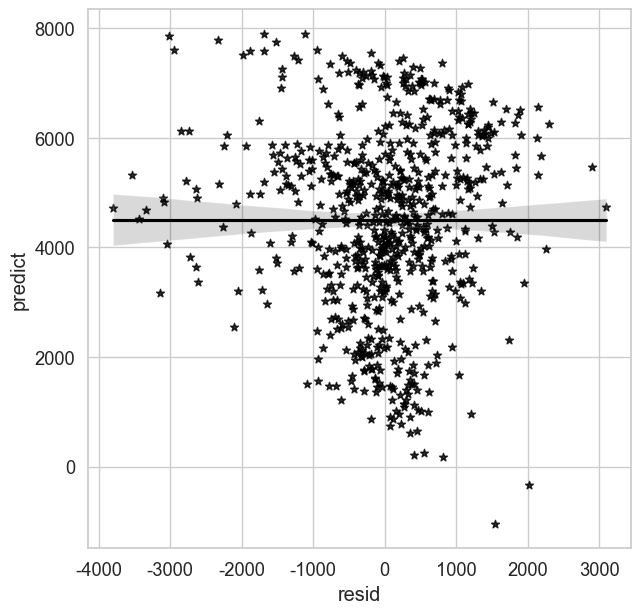

In [25]:
#2.残差与predict之间应该不相关
#regplot默认参数线性回归图
plt.figure(figsize=(7, 7))
sns.set(style="whitegrid",font_scale=1.2)#设置主题，文本大小
g=sns.regplot(x='resid', y='predict', data=target_df,
             color='#000000',#设置marker及线的颜色
             marker='*',#设置marker形状
             )
plt.show()

#该模型的调整后R方是0.760，表示该模型解释了目标结果76%的总方差，拟合度较优，可解释程度较高。

观察权重（图中coef列）（由于本数据集使用了原始值，即未进行标准化和归一化，因此可以直接进行表述）：

温度（数值特征）：当所有其他特征保持不变时，将温度升高1℃，自行车的预测数量增加110辆。

风速（数值特征）：当所有其他特征保持不变时，风速增加1km/h，自行车的预测数量减少42辆。

天气情况（分类特征）：所有其他特征保持不变，雨雪天气的自行车的预测数量比晴天减少了1901辆；天气为雾时，自行车的预测数量比晴天减少了379辆。

季节（分类特征）：所有其他特征保持不变，夏天自行车的预测数量比春天增加了899辆，秋天自行车的预测数量比春天增加了138辆，冬天自行车的预测数量比春天增加了425辆。

是否假期（分类特征）：所有其他特征保持不变，假期的自行车预测数量比非假期减少了425辆。

本例中，截距的权重为2491，表示当处于春天、晴天、假期、工作日，温度、湿度、风速都为0，且为2011年1月1号时，预测的自行车数量为2399辆。

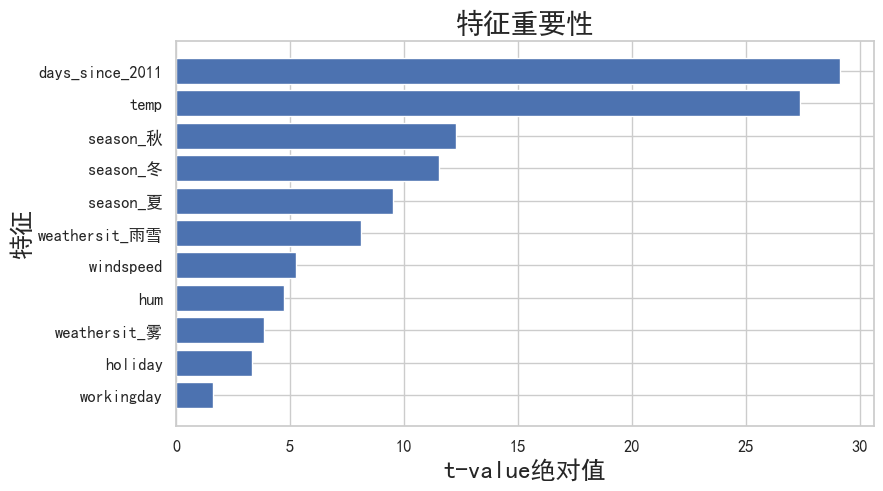

In [28]:
df_coef.index = df_coef['feature']
plot_df=df_coef.drop(index='Intercept') #删除截距行
plot_df=plot_df.sort_values(['t_abs']) #排序

fig = plt.figure(figsize = (9,5))
plt.barh(plot_df.index,plot_df['t_abs']) #画水平条形图

#设置x轴y轴
plt.xlabel('t-value绝对值',fontsize=18)
plt.ylabel('特征',fontsize=18)
plt.xticks(fontsize=12) #放大横纵坐标刻度线上的特征名字体
plt.yticks(fontsize=12)
plt.title('特征重要性',fontsize=20)
plt.show()
#由下图可知，最重要的特征为距离2011年第一天的天数，排名第二的为温度，排名第三的为是否是雨雪天气。

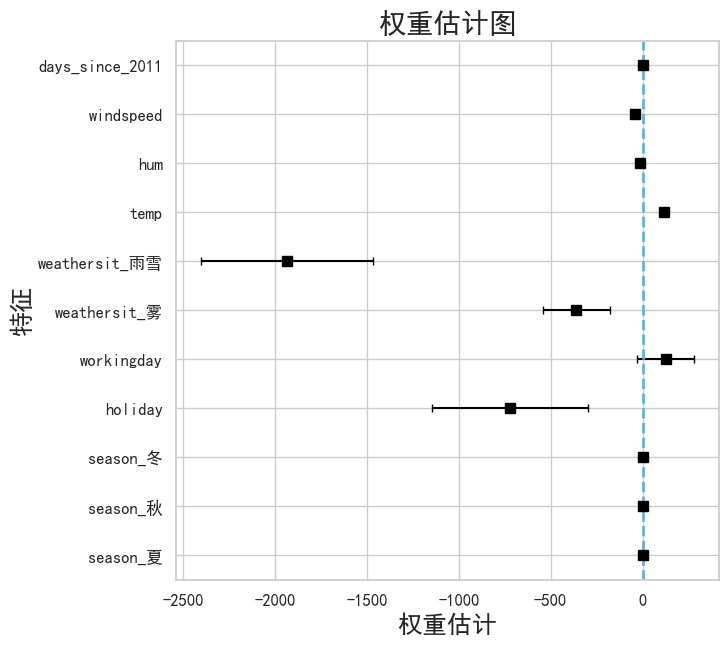

In [30]:
plot_df=df_coef.drop(index='Intercept') #删除截距行
fig = plt.figure(figsize = (7,7))
#由于上下误差相同，因此直接用 xerr=plot_df['lw_err']，否则可以使用xerr=plot_df[['lw_err','up_err']].T.values来分别规定上下限
plt.errorbar(x=plot_df['coef'], y=plot_df.index,xerr=plot_df['lw_err'], color="black", capsize=3,
             linestyle="None",
             marker="s", markersize=7, mfc="black", mec="black")

plt.grid(True) #显示网格线

plt.xlabel('权重估计',fontsize=18)
plt.ylabel('特征',fontsize=18)
plt.xticks(fontsize=12) #放大横纵坐标刻度线上的特征名字体
plt.yticks(fontsize=12)
plt.title('权重估计图',fontsize=20)

plt.axvline(c="c",ls="--",lw=2) #原点竖线
plt.show()

由上图可知：

1.雨雪天气对自行车租赁量有很大的负效应。

2.是否工作日的权重接近于0，并且95%的置信区间包含0，这表明该效应在统计上不显著。

3.温度的置信区间很短，估计值接近于0，但特征效应在统计上是显著的。

权重图的问题：

各个特征的量纲不一样，比如天气情况反映了晴天和雨雪天的差异，但是温度只反映了1℃的变化情况。

因此可以通过在建模前对特征进行标准化（均值为0，标准差为1），使估计的权重更具有可比性。

In [31]:
#求特征效应——每个特征的权重乘以实例的特征值
w=df_coef['coef'].values
w_order=[] #将特征权重与实例中的顺序一一对应
my_dict={0:4,1:5,2:8,3:9,4:10,5:11,6:3,7:1,8:2,9:6,10:7} #权重表与数据集中特征的对应顺序
for i in range(11):
    w_order.insert(i,w[my_dict[i]])

#计算特征效应
effect=X_train*w_order

#分类特征合并
effect['season']=np.sum(effect[['season_冬','season_夏','season_秋']],axis=1)
effect['weathersit']=np.sum(effect[['weathersit_雾','weathersit_雨雪']],axis=1)
effect

,holiday,workingday,temp,hum,windspeed,days_since_2011,season_冬,season_夏,season_秋,weathersit_雾,weathersit_雨雪,season,weathersit
0,-0.0,0.000000,963.453572,-1262.576181,-412.214153,0.000000,0.0,0.0,0.0,-360.60633,-0.0,0.0,-360.60633
1,-0.0,0.000000,1070.408438,-1090.626552,-638.540652,4.924027,0.0,0.0,0.0,-360.60633,-0.0,0.0,-360.60633
2,-0.0,126.107777,144.839819,-685.117728,-637.949741,9.848054,0.0,0.0,0.0,-0.00000,-0.0,0.0,0.00000
3,-0.0,126.107777,164.977974,-925.091387,-411.828777,14.772081,0.0,0.0,0.0,-0.00000,-0.0,0.0,0.00000
4,-0.0,126.107777,314.280565,-684.622621,-480.179158,19.696108,0.0,0.0,0.0,-0.00000,-0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,-0.0,126.107777,464.984409,-1022.987954,-899.553608,3574.843659,0.0,0.0,0.0,-360.60633,-0.0,0.0,-360.60633
727,-0.0,126.107777,460.365261,-924.409830,-399.432498,3579.767686,0.0,0.0,0.0,-360.60633,-0.0,0.0,-360.60633
728,-0.0,0.000000,460.365261,-1179.667587,-319.561928,3584.691713,0.0,0.0,0.0,-360.60633,-0.0,0.0,-360.60633
729,-0.0,0.000000,474.211627,-757.284367,-901.149067,3589.615740,0.0,0.0,0.0,-0.00000,-0.0,0.0,0.00000


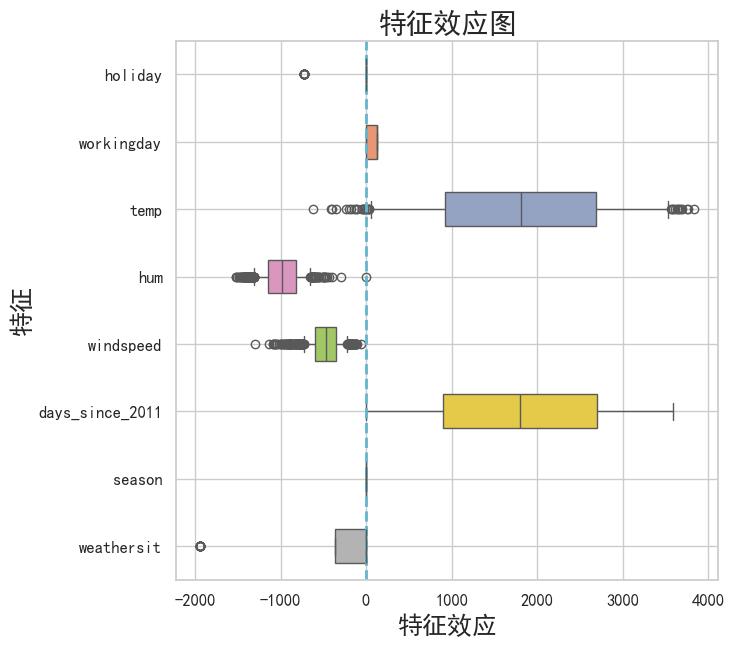

In [33]:
plt.subplots(figsize=(7, 7))

cols=['holiday', 'workingday', 'temp', 'hum', 'windspeed', 'days_since_2011',
       'season', 'weathersit']
sns.boxplot(data=effect[cols],orient="h",width=0.5,whis=0.5, palette="Set2")

plt.grid(True) #显示网格线

plt.xlabel('特征效应',fontsize=18)
plt.ylabel('特征',fontsize=18)
plt.xticks(fontsize=12) #放大横纵坐标刻度线上的特征名字体
plt.yticks(fontsize=12)
plt.title('特征效应图',fontsize=20)

plt.axvline(c="c",ls="--",lw=2) #原点竖线
plt.show()
#由下图可知：
#1.对预测自行车租赁数量正向贡献最大的来自温度和天数。
#2.天气的情况参照类别为晴天，图中说明除了晴天外的天气（雾、雨雪）都会对自行车租赁量产生负向影响。

In [36]:
single_idx=5 #第6个实例
print(bike_ohe.loc[single_idx])


cnt                1606.000000
holiday               0.000000
workingday            1.000000
temp                  1.604356
hum                  51.826100
windspeed             6.000868
days_since_2011       5.000000
season_冬              0.000000
season_夏              0.000000
season_秋              0.000000
weathersit_雾          0.000000
weathersit_雨雪         0.000000
Name: 5, dtype: float64


In [35]:
target_predict=target_df.loc[single_idx,'predict']
target_predict_mean=np.mean(target_df['predict'])
target_true=target_df.loc[single_idx,'true']
print('该实例预测值',target_predict)
print('所有实例平均预测值',target_predict_mean)
print('该实例实际值',target_true)

该实例预测值 1788.8965195193123
所有实例平均预测值 4504.348837209256
该实例实际值 1606


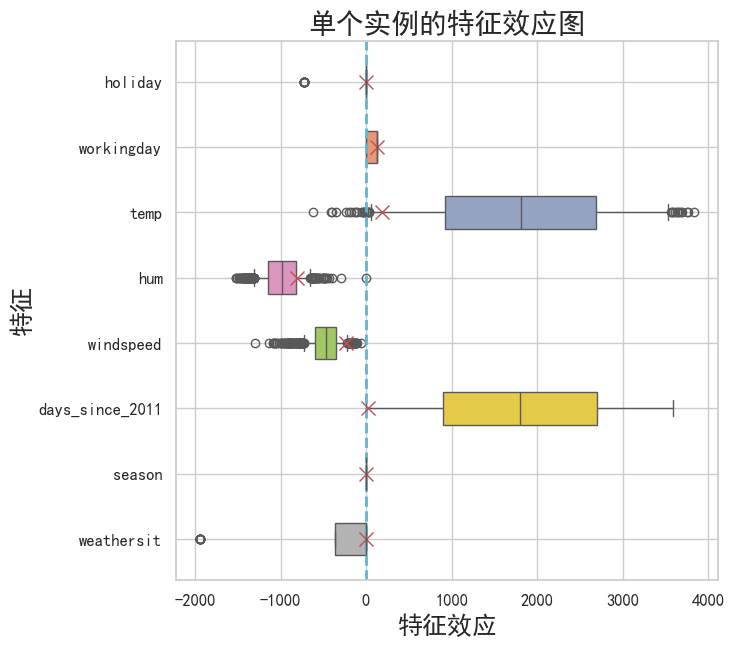

In [38]:
plt.subplots(figsize=(7, 7))

cols=['holiday', 'workingday', 'temp', 'hum', 'windspeed', 'days_since_2011',
       'season', 'weathersit']
sns.boxplot(data=effect[cols],orient="h",width=0.5,whis=0.5, palette="Set2")

plt.grid(True) #显示网格线

plt.xlabel('特征效应',fontsize=18)
plt.ylabel('特征',fontsize=18)
plt.xticks(fontsize=12) #放大横纵坐标刻度线上的特征名字体
plt.yticks(fontsize=12)
plt.title('单个实例的特征效应图',fontsize=20)

plt.axvline(c="c",ls="--",lw=2) #原点竖线



#画单个实例中每个特征的效应
for col in cols:
    col_index=cols.index(col) #获取某个特征在特征名列表的索引位置
    plt.plot(effect.loc[single_idx,col], col_index,'rx', ms=10)  #rx 红色叉号，ms控制大小

plt.show()

以数据集中第6个实例为例：
相较于所有实例的平均预测值4504辆，该实例的预测值很小，只有1571辆自行车被租赁。

效应图揭示了原因：

1.该实例温度的特征效应较小，这一天温度仅为1.6℃，与其他大多数日期的温度相比较低（温度权重为正）。

2.该实例天数的特征效应也较小，该实例自第一天起仅过了5天（天数权重为正）。